# Housing Price Prediction
## Exploratory / Development Notebook
*By Tom Biefel, Kishan Dhulashia, Álvaro Perez La Rosa, Robyn Rothlin, Carlos Suarez Álvarez,  and Natalia Urrea Lopez*

This notebook is an exploratory sandbox that mirrors the production pipeline defined in `main.py`.
All heavy logic lives in the `src/` modules; this notebook calls those functions in the same order as the orchestrator.

### A) Environment setup and imports

- Make imports reliable regardless of how Jupyter was opened
- Ensure relative paths behave the same way for everyone
- Keep notebook code thin by calling functions from `src/` modules

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import os       # For changing the working directory to the repo root
import sys      # For manipulating sys.path so imports work wherever Jupyter started
from pathlib import Path  # Platform-independent file paths

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from IPython.display import display  # Displays DataFrames nicely in Jupyter

#   Search upward from the current folder until we find a folder that contains `src/`,
#   then set that as the working directory so paths match the orchestrator behaviour.
def find_repo_root(start: Path, marker_dir: str = "src", max_hops: int = 12) -> Path:
    current = start.resolve()
    for _ in range(max_hops):
        if (current / marker_dir).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise RuntimeError(
        f"Could not find repo root containing '{marker_dir}/' starting from: {start}"
    )

PROJECT_ROOT = find_repo_root(Path.cwd())
os.chdir(PROJECT_ROOT)

# Ensure `import src.*` works even if Jupyter started elsewhere
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd:", Path.cwd())

# ── Imports from production modules ─────────────────────────────────────────
# We intentionally do NOT import from main.py.
# Each module is imported individually so we can call stages interactively.
from src.load_data import ensure_raw_data_exists, load_raw_data
from src.clean_data import clean_dataframe
from src.validate import validate_dataframe
from src.features import get_feature_preprocessor
from src.train import train_model
from src.evaluate import evaluate_model, save_evaluation_plots
from src.infer import run_inference
from src.utils import save_csv, save_model

PROJECT_ROOT: /Users/carlosasuarez/Projects/G2_MLOPS_Project
cwd: /Users/carlosasuarez/Projects/G2_MLOPS_Project


### B) Sandbox configuration

- Keep all configuration in one place at the top
- Use the same column names and paths as the orchestrator (`main.py`)
- Prefer explicit values over magic inference so errors are actionable

In [3]:
CONFIG_PATH = PROJECT_ROOT / "config.yaml"
with CONFIG_PATH.open("r", encoding="utf-8") as fh:
    cfg = yaml.safe_load(fh)

paths_cfg = cfg["paths"]
features_cfg = cfg["features"]
validation_cfg = cfg["validation"]
problem_cfg = cfg["problem"]
split_cfg = cfg["split"]
training_cfg = cfg["training"]
evaluation_cfg = cfg["evaluation"]

RAW_DATA_PATH = (PROJECT_ROOT / paths_cfg["raw_data"]).resolve()
PROCESSED_PATH = (PROJECT_ROOT / paths_cfg["processed_data"]).resolve()
MODEL_PATH = (PROJECT_ROOT / paths_cfg["model_artifact"]).resolve()
INFERENCE_DATA_PATH = (PROJECT_ROOT / paths_cfg["inference_data"]).resolve()
PREDICTIONS_PATH = (PROJECT_ROOT / paths_cfg["predictions_artifact"]).resolve()
REPORTS_DIR = PREDICTIONS_PATH.parent
MODELS_DIR = MODEL_PATH.parent

TARGET_COLUMN = problem_cfg["target_column"]

REQUIRED_COLUMNS = features_cfg["required_columns"]
NUMERIC_COLS = features_cfg["numeric_passthrough"]
CATEGORICAL_COLS = features_cfg["categorical_onehot"]
BINARY_COLS = features_cfg["binary_cols"]
VALID_FURNISHING_VALUES = features_cfg["valid_furnishing_values"]
NON_NEGATIVE_COLS = validation_cfg["numeric_non_negative_cols"]

N_FOLDS = split_cfg.get("n_folds", 5)
RANDOM_STATE = split_cfg.get("random_state", 42)
SHUFFLE = split_cfg.get("shuffle", True)
FIT_INTERCEPT = training_cfg.get("regression", {}).get("fit_intercept", True)

print("Loaded config from:", CONFIG_PATH)
print("Target column:", TARGET_COLUMN)
print("Required columns:", REQUIRED_COLUMNS)

Loaded config from: /Users/carlosasuarez/Projects/G2_MLOPS_Project/config.yaml
Target column: price
Required columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


### 1) Load raw data (`src.load_data`)

- We load raw data exactly once and treat it as immutable input
- `ensure_raw_data_exists` downloads the file from Kaggle automatically when it is absent

In [4]:
ensure_raw_data_exists(RAW_DATA_PATH, fetch_if_missing=True)

df_raw = load_raw_data(RAW_DATA_PATH)
print("df_raw.shape:", df_raw.shape)
df_raw.head()

df_raw.shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### 2) Focused EDA checks

Goal
- Validate assumptions before investing in feature engineering and training

- Prefer small, targeted checks over long notebooks
- If an assumption is wrong, fix the upstream module or the data contract

In [5]:
# Data types and non-null counts
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [6]:
print(f"Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

# Missing values
nan_count = df_raw.isna().sum()
print("\nMissing values per column:")
display(nan_count[nan_count > 0] if nan_count.sum() > 0 else "No missing values")

Dataset shape: 545 rows × 13 columns

Missing values per column:


'No missing values'

In [7]:
# Summary statistics for numeric features
df_raw.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Target: 'price'
  min  : 1,750,000
  median: 4,340,000
  max  : 13,300,000


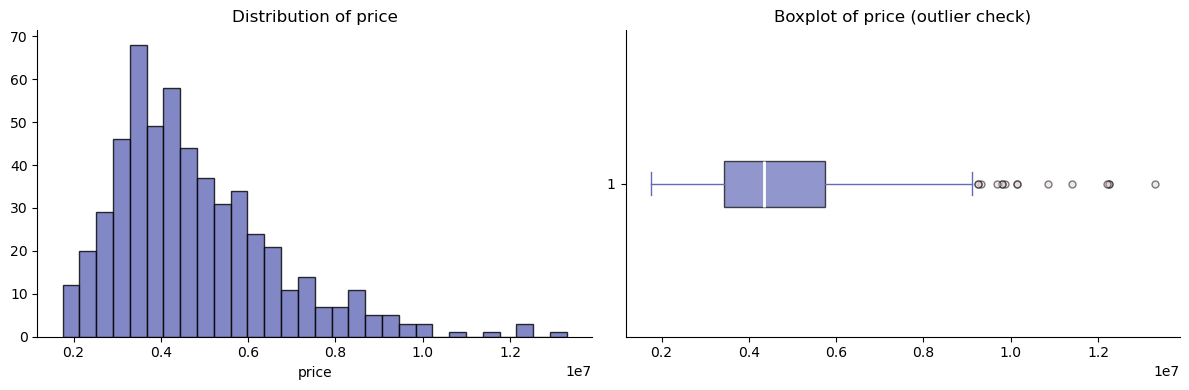

In [8]:
# Target variable distribution
print(f"Target: '{TARGET_COLUMN}'")
print(f"  min  : {df_raw[TARGET_COLUMN].min():,.0f}")
print(f"  median: {df_raw[TARGET_COLUMN].median():,.0f}")
print(f"  max  : {df_raw[TARGET_COLUMN].max():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df_raw[TARGET_COLUMN], bins=30, color="#636bb8", edgecolor="black", alpha=0.8)
axes[0].set_title("Distribution of price")
axes[0].set_xlabel("price")
axes[0].spines[["top", "right"]].set_visible(False)

# Boxplot
axes[1].boxplot(df_raw[TARGET_COLUMN], vert=False, patch_artist=True,
                boxprops=dict(facecolor="#636bb8", alpha=0.7),
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(color="#636bb8"),
                capprops=dict(color="#636bb8"),
                flierprops=dict(markerfacecolor="#e0d1d4", marker="o", markersize=5, alpha=0.5))
axes[1].set_title("Boxplot of price (outlier check)")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

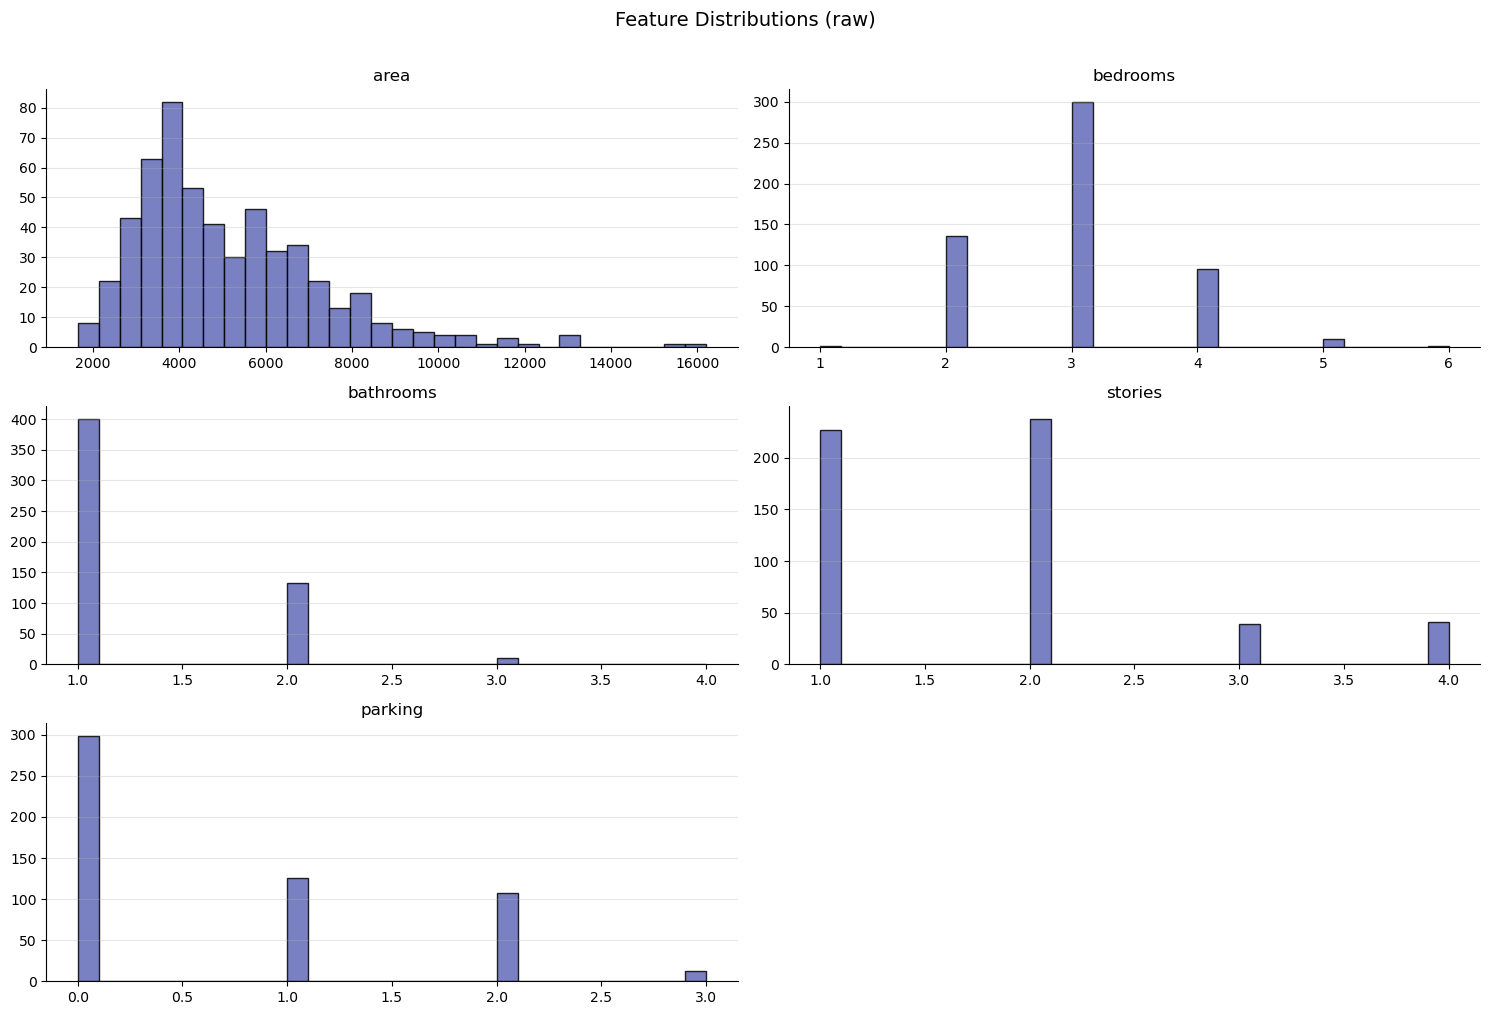

In [9]:
# Distributions of all numeric features
axes = df_raw[NUMERIC_COLS].hist(bins=30, figsize=(15, 10),
                                      color="#636bb8", edgecolor="black",
                                      alpha=0.85, grid=False)
for ax_row in axes:
    for ax in ax_row:
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.3)
plt.suptitle("Feature Distributions (raw)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

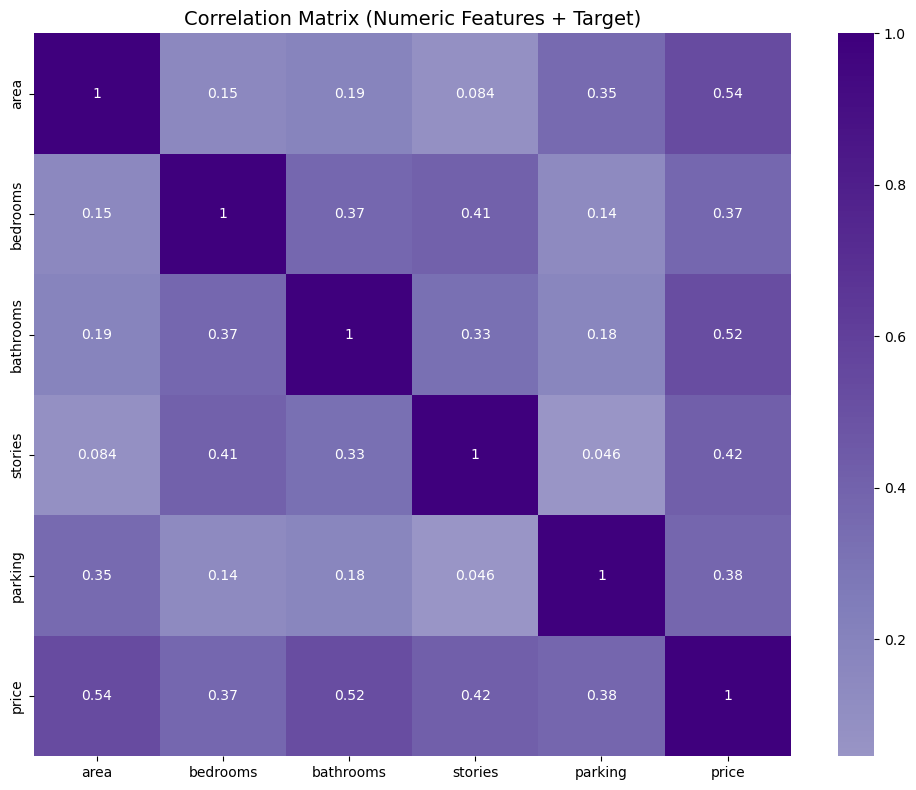

Highly correlated pairs (|r| > 0.8):
  None found


In [10]:
# Correlation matrix
numeric_cols = ["area", "bedrooms", "bathrooms", "stories", "parking"]
corr = df_raw[numeric_cols + [TARGET_COLUMN]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="Purples", center=0, annot=True, square=False, ax=ax)
ax.set_title("Correlation Matrix (Numeric Features + Target)", fontsize=14)
plt.tight_layout()
plt.show()

# Flag any strongly correlated feature pairs (> 0.80)
CORR_THRESHOLD = 0.80
high_corr = (corr[numeric_cols].where(
                np.triu(np.ones(corr[numeric_cols].shape), k=1).astype(bool))
             .stack().loc[lambda x: x.abs() > CORR_THRESHOLD])
print(f"Highly correlated pairs (|r| > {CORR_THRESHOLD}):")
print(high_corr if len(high_corr) else "  None found")

### 3) Clean data (`src.clean_data`)

- Cleaning should be deterministic and stateless, it must not learn from the data
- All cleaning logic lives in `src/clean_data.py`; this cell is a thin wrapper

In [11]:
df_clean = clean_dataframe(df_raw)
print("df_clean.shape:", df_clean.shape)
df_clean.head()

df_clean.shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### 4) What changed after cleaning?

- Make transformations visible
- Help debug unexpected column name changes or dropped columns

In [12]:
raw_cols   = list(df_raw.columns)
clean_cols = list(df_clean.columns)

removed = sorted(set(raw_cols)   - set(clean_cols))
added   = sorted(set(clean_cols) - set(raw_cols))

print("Columns removed:", removed if removed else "none")
print("Columns added  :", added   if added   else "none")
print(f"Row count: {len(df_raw)} → {len(df_clean)}")

Columns removed: none
Columns added  : none
Row count: 545 → 545


### 5) Validate data: Security gate (`src.validate`)

- Validation is a fail-fast gate: it prevents wasting time training on broken assumptions
- If validation fails, fix the upstream module or data contract and not the notebook

In [13]:
# Convert yes/no binary columns to 1/0 only for validation
df_for_validation = df_clean.copy()

for col in BINARY_COLS:
    if col in df_for_validation.columns:
        normalized = df_for_validation[col].astype(str).str.strip().str.lower()
        if set(normalized.dropna().unique()).issubset({"yes", "no"}):
            df_for_validation[col] = normalized.map({"yes": 1, "no": 0})

validate_dataframe(
    df_for_validation,
    required_columns=REQUIRED_COLUMNS,
    binary_cols=BINARY_COLS,
    valid_furnishing_values=VALID_FURNISHING_VALUES,
    non_negative_cols=NON_NEGATIVE_COLS,
    target_column=TARGET_COLUMN,
)
print("Validation passed")

Validation passed


### 6) Build the feature recipe (`src.features`)

Educational note
- This step builds a preprocessing **blueprint** — an unfitted `ColumnTransformer`
- It must not be fitted on the full dataset in the notebook
- The recipe only learns (calls `.fit()`) when passed into `train_model()`, where it is fitted on fold-train data only — never on the full dataset or test rows

In [14]:
preprocessor = get_feature_preprocessor(
    numeric_cols=NUMERIC_COLS,
    categorical_cols=CATEGORICAL_COLS,
    binary_cols=BINARY_COLS,
)

print("[notebook] Feature recipe built, not fitted yet")
preprocessor

[notebook] Feature recipe built, not fitted yet


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

### 7) Split into training and inference holdout

Educational note
- The split happens **after** the recipe is defined, mirroring the pipeline contract: the recipe is passed into training, where it is fitted on fold-train rows only
- 50 rows are held out as an inference smoke-test set, matching `main.py`
- The target is dropped from the inference set to simulate real-world unseen data

In [15]:
df_infer = df_clean.sample(n=50, random_state=42)
df_train = df_clean.drop(df_infer.index)

X_infer  = df_infer.drop(columns=[TARGET_COLUMN])

print(f"Training set : {df_train.shape}  (used for 5-fold CV)")
print(f"Inference set: {X_infer.shape}   (target hidden — simulates production)")

Training set : (495, 13)  (used for 5-fold CV)
Inference set: (50, 12)   (target hidden — simulates production)


### 8) Train (`src.train`)

- `train_model` runs 5-fold cross-validation on the full training set
- K-fold CV provides robust performance estimates without needing a separate test set
- The returned `pipeline` encapsulates preprocessing + the model, ready for inference

In [16]:
# Convert yes/no binary columns to 1/0 for model training
df_train_for_model = df_train.copy()

for col in BINARY_COLS:
    if col in df_train_for_model.columns:
        normalized = df_train_for_model[col].astype(str).str.strip().str.lower()
        if set(normalized.dropna().unique()).issubset({"yes", "no"}):
            df_train_for_model[col] = normalized.map({"yes": 1, "no": 0})

pipeline, cv_results = train_model(
    df=df_train_for_model,
    target_column=TARGET_COLUMN,
    preprocessor=preprocessor,
    n_folds=N_FOLDS,
    random_state=RANDOM_STATE,
    shuffle=SHUFFLE,
    fit_intercept=FIT_INTERCEPT,
    numeric_cols=NUMERIC_COLS,
    categorical_cols=CATEGORICAL_COLS,
    binary_cols=BINARY_COLS,
)

print("[notebook] Training complete")
pipeline

[notebook] Training complete


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

### 9) Evaluate (`src.evaluate`)

- `evaluate_model` computes aggregate metrics from K-fold CV results
- All scores are on the original price scale for interpretability
- `save_evaluation_plots` writes `actual_vs_predicted.png` and `residuals.png` to the reports directory

In [17]:
metrics = evaluate_model(cv_results)
print("[notebook] K-fold CV metrics:")
for k, v in metrics.items():
    print(f"  {k:20s}: {v:.4f}")

[notebook] K-fold CV metrics:
  r2                  : 0.6427
  adjusted_r2         : 0.6331
  mae                 : 763315.1897
  rmse                : 1056651.8001


In [18]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
save_evaluation_plots(cv_results, reports_dir=REPORTS_DIR)
print(f"[notebook] Evaluation plots saved → {REPORTS_DIR}")

[notebook] Evaluation plots saved → /Users/carlosasuarez/Projects/G2_MLOPS_Project/reports


### 10) Inference demo (`src.infer`)

- Inference simulates what happens in production: the pipeline sees only features, never the target
- `run_inference` applies the same preprocessing pipeline fitted during training, preventing leakage

In [19]:
# Convert yes/no binary columns to 1/0 for inference (same as training)
X_infer_for_model = X_infer.copy()

for col in BINARY_COLS:
	if col in X_infer_for_model.columns:
		normalized = X_infer_for_model[col].astype(str).str.strip().str.lower()
		if set(normalized.dropna().unique()).issubset({"yes", "no"}):
			X_infer_for_model[col] = normalized.map({"yes": 1, "no": 0})

predictions = run_inference(pipeline, X_infer_for_model)

print("[notebook] Predictions on 50-row holdout:")
display(predictions.head(10))

[notebook] Predictions on 50-row holdout:


,prediction
316,4.452548e+06
77,7.129327e+06
360,3.297847e+06
90,4.546260e+06
493,3.336158e+06
209,3.399239e+06
176,5.280382e+06
249,6.296223e+06
516,2.790856e+06
426,2.771963e+06


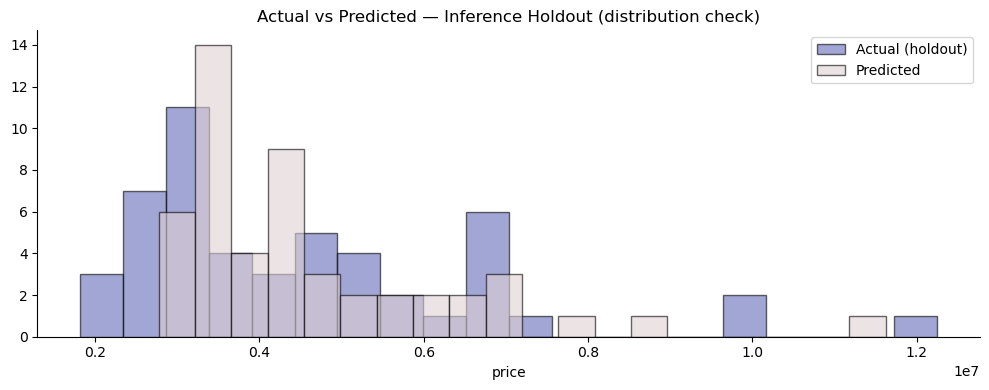

In [20]:
# Quick sense-check: predicted price distribution vs actuals
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(df_infer[TARGET_COLUMN], bins=20, alpha=0.6, color="#636bb8",
        label="Actual (holdout)", edgecolor="black")
ax.hist(predictions["predicted_price"] if "predicted_price" in predictions.columns
        else predictions.iloc[:, 0],
        bins=20, alpha=0.6, color="#e0d1d4",
        label="Predicted", edgecolor="black")

ax.set_xlabel("price")
ax.set_title("Actual vs Predicted — Inference Holdout (distribution check)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 11) Inspect production artifacts from the orchestrator

This notebook does not write artifacts to disk.

Use this cell only **after** running the full pipeline from the terminal:
```bash
python -m src.main
```

Goal
- Prove that the pipeline output exists on disk
- Inspect outputs without modifying them

In [21]:
from src.utils import load_model
import glob

CLEAN_DATA_PATH = PROCESSED_PATH

# Find model and prediction artifacts using config paths
model_files = sorted(glob.glob(str(MODELS_DIR / "model*.joblib")))
prediction_file = PREDICTIONS_PATH

try:
    clean_from_disk = pd.read_csv(CLEAN_DATA_PATH)
    print("clean.csv shape   :", clean_from_disk.shape)
except FileNotFoundError:
    print("clean.csv not found - run main.py first")

if model_files:
    latest_model_path = model_files[-1]
    model_from_disk = load_model(latest_model_path)
    print("Latest model      :", latest_model_path)
    print("Pipeline steps    :", [s[0] for s in model_from_disk.steps])
else:
    print("No model files found - run main.py first")

if prediction_file.exists():
    preds_from_disk = pd.read_csv(prediction_file)
    print("Predictions file  :", prediction_file)
    print("Number of predictions:", len(preds_from_disk))
    display(preds_from_disk.head())
else:
    print(f"Predictions file not found at {prediction_file} - run main.py first")

clean.csv shape   : (545, 13)
Latest model      : /Users/carlosasuarez/Projects/G2_MLOPS_Project/models/model_20260305_192606.joblib
Pipeline steps    : ['preprocess', 'model']
Predictions file  : /Users/carlosasuarez/Projects/G2_MLOPS_Project/reports/predictions.csv
Number of predictions: 20


,prediction
0,2.903259e+06
1,5.951893e+06
2,8.774110e+06
3,2.413822e+06
4,6.118580e+06
